In [1]:
#Import libraries
import numpy as npo
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
#Loading dataset
df = pd.read_csv('customer_support_tickets.csv')df.head()

,Ticket_ID,Created_Date,Resolved_Date,Category,Priority,Agent,Resolution_Time_Hours,Customer_Rating
0,T001,2024-01-02,2024-01-03,Login Issue,High,Amit,12,4
1,T002,2024-01-02,2024-01-04,Payment Issue,Medium,Ravi,36,3
2,T003,2024-01-03,2024-01-03,Account Setup,Low,Sneha,4,5
3,T004,2024-01-04,2024-01-06,Login Issue,High,Amit,48,2
4,T005,2024-01-05,2024-01-05,Technical Error,Medium,Sneha,6,4


In [19]:
#Finding errors and checking null values and data types and qunique data values
print(df.isnull().sum())
print(df.dtypes)
print(df['Category'].unique())
print(df['Priority'].unique())
print(df['Agent'].unique())

Ticket_ID                0
Created_Date             0
Resolved_Date            0
Category                 0
Priority                 0
Agent                    0
Resolution_Time_Hours    0
Customer_Rating          0
dtype: int64
Ticket_ID                object
Created_Date             object
Resolved_Date            object
Category                 object
Priority                 object
Agent                    object
Resolution_Time_Hours     int64
Customer_Rating           int64
dtype: object
['Login Issue' 'Payment Issue' 'Account Setup' 'Technical Error']
['High' 'Medium' 'Low']
['Amit' 'Ravi' 'Sneha']


In [32]:
#Converting date type (obj) to datetime data type for feature data analysis..,
df['Created_Date']=pd.to_datetime(df['Created_Date'])
df['Resolved_Date']=pd.to_datetime(df['Resolved_Date'])
df.dtypes

Ticket_ID                        object
Created_Date             datetime64[ns]
Resolved_Date            datetime64[ns]
Category                         object
Priority                         object
Agent                            object
Resolution_Time_Hours             int64
Customer_Rating                   int64
dtype: object

In [46]:
#Creating month column and Resolution_days column
df['Created_Month']=df['Created_Date'].dt.to_period('M')
df['Resolution_Days'] = (df['Resolved_Date'] - df['Created_Date']).dt.days
df.head(5)

,Ticket_ID,Created_Date,Resolved_Date,Category,Priority,Agent,Resolution_Time_Hours,Customer_Rating,Created_Month,Resolution_Days
0,T001,2024-01-02,2024-01-03,Login Issue,High,Amit,12,4,2024-01,1
1,T002,2024-01-02,2024-01-04,Payment Issue,Medium,Ravi,36,3,2024-01,2
2,T003,2024-01-03,2024-01-03,Account Setup,Low,Sneha,4,5,2024-01,0
3,T004,2024-01-04,2024-01-06,Login Issue,High,Amit,48,2,2024-01,2
4,T005,2024-01-05,2024-01-05,Technical Error,Medium,Sneha,6,4,2024-01,0


In [59]:
#Creating group by for Created_Month and total number of tickets count
lineplot=df.groupby('Created_Month')['Ticket_ID'].count().reset_index()

#Converting data type 'Period' to string 
#After group by it was converted to 'Period' data type this data type it will accept line chart thats why we are converting to str data type
lineplot['Created_Month']=lineplot['Created_Month'].astype(str)

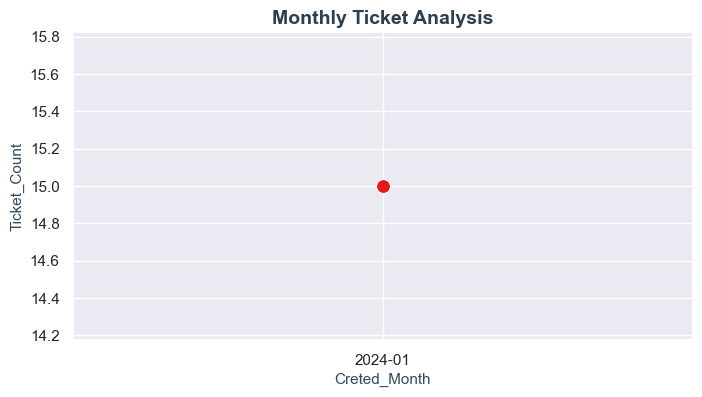

In [144]:
#Line Plot

#Creating plot width & height
plt.figure(figsize=(8,4))

#Giving plot theme and style
sns.set_style('darkgrid')
sns.set_context('notebook')

#Creating Line Plot
sns.lineplot(data=lineplot,x='Created_Month',y='Ticket_ID',marker='o',markersize=10,palette='Set1',hue='Created_Month',legend=False);

#Creating font dictionary 
f1={'family':'sans-serif','size':14,'color':'#2c3e50','weight':'bold'}
f2={'family':'sans-serif','size':11,'color':'#34495e','weight':'medium'}

#Applying font dictionary and giving names to x,y labels and title
plt.title('Monthly Ticket Analysis',fontdict=f1)
plt.xlabel('Creted_Month',fontdict=f2)
plt.ylabel('Ticket_Count',fontdict=f2);

#final otput 
plt.show()

**Insight:** In January 2024, a total of 15 tickets were created. Since the dataset contains data for only one month, trend analysis over time is currently not possible.

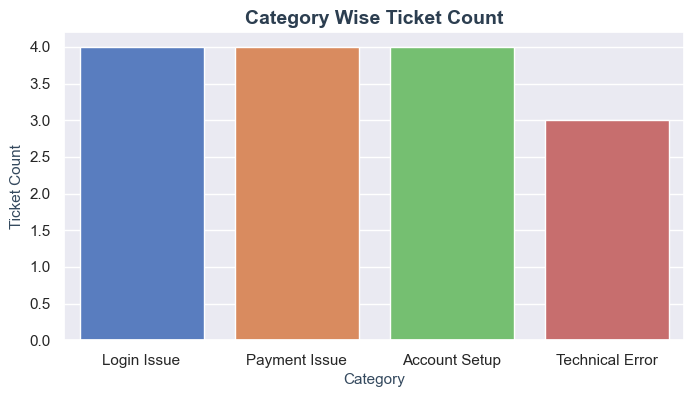

In [158]:
#Count Plot

#Creating plot width & height
plt.figure(figsize=(8,4))

#Giving plot theme and style
sns.set_style('darkgrid')
sns.set_context('notebook')

#Creating Count Plot
sns.countplot(data=df,x='Category',palette='muted',hue='Category',legend=False);

#Creating font dictionary 
f3={'family':'sans-serif','size':14,'weight':'bold','color':'#2c3e50'}
f4={'family':'sans-serif','size':11,'weight':'medium','color':'#34495e'}

#Applying font dictionary and giving names to x,y labels and title
plt.title('Category Wise Ticket Count',fontdict=f3)
plt.xlabel('Category',fontdict=f4)
plt.ylabel('Ticket Count',fontdict=f4);

#final otput 
plt.show()

**Insight:** Login Issue, Payment Issue, and Account Setup categories have the highest number of tickets, indicating frequent user-facing problems, while Technical Error tickets occur slightly less often.

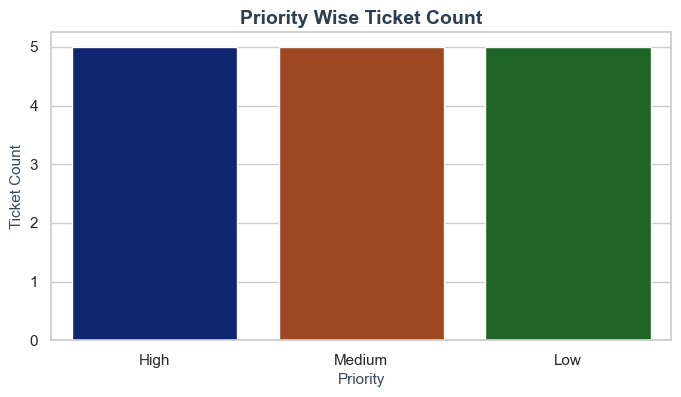

In [157]:
#Count Plot

#Creating plot width & height
plt.figure(figsize=(8,4))

#Giving plot theme and style
sns.set_style('whitegrid')
sns.set_context('notebook')

#Creating Count Plot
sns.countplot(data=df,x='Priority',palette='dark',hue='Priority',legend=False);

#Creating font dictionary 
f5={'family':'sans-serif','weight':'bold','size':14,'color':'#2c3e50'}
f6={'family':'sans-serif','weight':'medium','size':11,'color':'#34495e'}

#Applying font dictionary and giving names to x,y labels and title
plt.title('Priority Wise Ticket Count',fontdict=f5)
plt.xlabel('Priority',fontdict=f6)
plt.ylabel('Ticket Count',fontdict=f6)

#final otput 
plt.show()

**Insight:** Ticket volume is evenly distributed across High, Medium, and Low priority levels, indicating that support issues are spread uniformly and no single priority category dominates the workload.

In [139]:
#Creating group by for Priority and Resolution_Time_Hours time
avg_time=df.groupby('Priority')['Resolution_Time_Hours'].mean().reset_index()
avg_time.dtypes

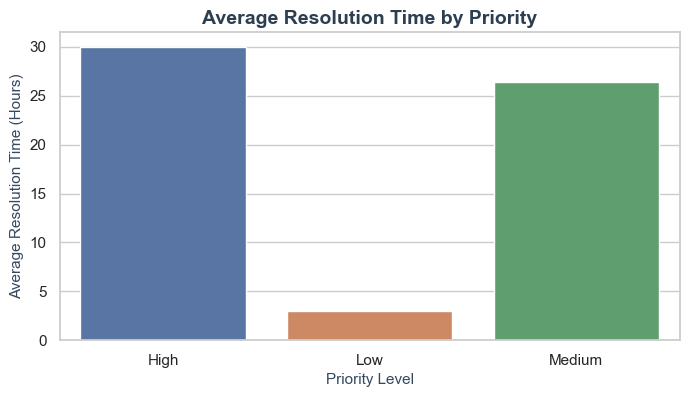

In [165]:
#Bar Plot

#Creating plot width & height
plt.figure(figsize=(8,4))

#Giving plot theme and style
sns.set_style('whitegrid')
sns.set_context('notebook')

#Creating Bar Plot
sns.barplot(data=avg_time,x='Priority',y='Resolution_Time_Hours',palette='deep',hue='Priority',legend=False);

#Creating font dictionary 
f7={'family':'sans-serif','weight':'bold','size':14,'color':'#2c3e50'}
f8={'family':'sans-serif','weight':'medium','size':11,'color':'#34495e'}

#Applying font dictionary and giving names to x,y labels and title
plt.title('Average Resolution Time by Priority',fontdict=f7)
plt.xlabel('Priority Level',fontdict=f8)
plt.ylabel('Average Resolution Time (Hours)',fontdict=f8)

#final otput 
plt.show()

**Insight:** High priority tickets have a higher average resolution time compared to Medium and Low priority tickets, indicating that urgent issues tend to be more complex and time-consuming to resolve.

In [169]:
#Creating group by for Agent and Resolution_Time_Hours time
agent_time=df.groupby('Agent')['Resolution_Time_Hours'].mean().reset_index()
avg_time.dtypes

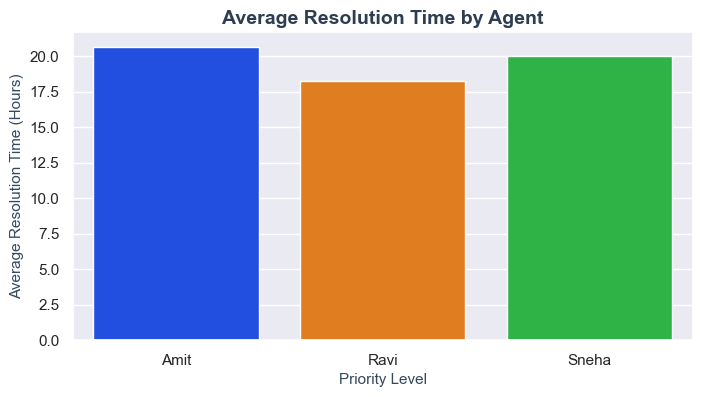

In [178]:
#Bar Plot

#Creating plot width & height
plt.figure(figsize=(8,4))

#Giving plot theme and style
sns.set_style('darkgrid')
sns.set_context('notebook')

#Creating Bar Plot
sns.barplot(data=agent_time,x='Agent',y='Resolution_Time_Hours',palette='bright',hue='Agent',legend=False)

#Creating font dictionary 
f9={'family':'sans-serif','weight':'bold','size':14,'color':'#2c3e50'}
f10={'family':'sans-serif','weight':'medium','size':11,'color':'#34495e'}

#Applying font dictionary and giving names to x,y labels and title
plt.title('Average Resolution Time by Agent',fontdict=f9)
plt.xlabel('Priority Level',fontdict=f10)
plt.ylabel('Average Resolution Time (Hours)',fontdict=f10)

#final otput 
plt.show()

**Insight:** Ravi has the lowest average resolution time, indicating faster ticket resolution compared to Amit and Sneha, while Amit shows the highest average resolution time.

In [179]:
df.head()

,Ticket_ID,Created_Date,Resolved_Date,Category,Priority,Agent,Resolution_Time_Hours,Customer_Rating,Created_Month,Resolution_Days
0,T001,2024-01-02,2024-01-03,Login Issue,High,Amit,12,4,2024-01,1
1,T002,2024-01-02,2024-01-04,Payment Issue,Medium,Ravi,36,3,2024-01,2
2,T003,2024-01-03,2024-01-03,Account Setup,Low,Sneha,4,5,2024-01,0
3,T004,2024-01-04,2024-01-06,Login Issue,High,Amit,48,2,2024-01,2
4,T005,2024-01-05,2024-01-05,Technical Error,Medium,Sneha,6,4,2024-01,0


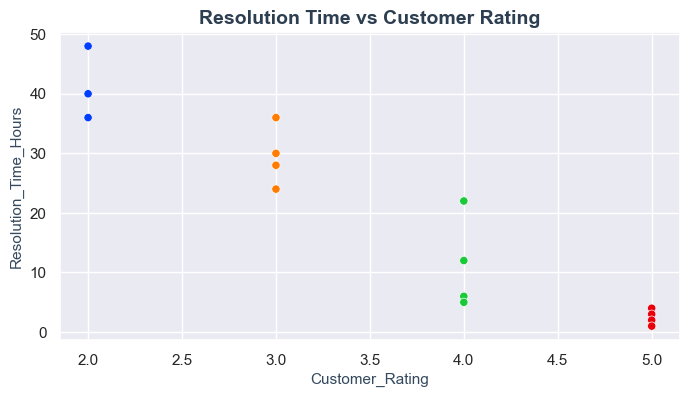

In [192]:
#Scatter Plot

#Creating plot width & height
plt.figure(figsize=(8,4))

#Giving plot theme and style
sns.set_style('darkgrid')
sns.set_context('notebook')

#Creating Scatter Plot
sns.scatterplot(data=df,x='Customer_Rating',y='Resolution_Time_Hours',palette='bright',hue='Customer_Rating',legend=False);

#Creating font dictionary 
f11={'family':'sans-serif','weight':'bold','size':14,'color':'#2c3e50'}
f12={'family':'sans-serif','weight':'medium','size':11,'color':'#34495e'}

#Applying font dictionary and giving names to x,y labels and title
plt.title('Resolution Time vs Customer Rating',fontdict=f11)
plt.xlabel('Customer_Rating',fontdict=f12)
plt.ylabel('Resolution_Time_Hours',fontdict=f12)

#final otput 
plt.show()

**Insight:** Higher customer ratings are associated with shorter resolution times, while longer resolution times tend to result in lower customer satisfaction, indicating a strong negative relationship.

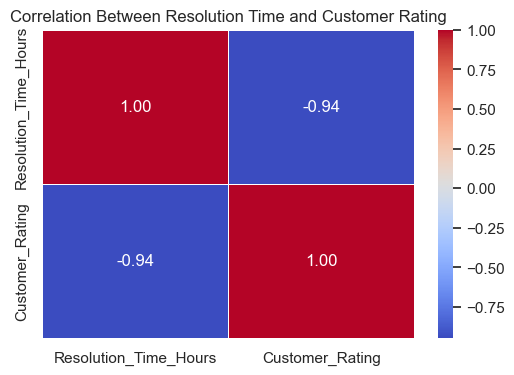

In [228]:
#Heat Map

# Select numeric columns
heat = df[['Resolution_Time_Hours', 'Customer_Rating']]

# Create correlation matrix
corr_matrix = heat.corr()

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Resolution Time and Customer Rating')

plt.show()

**Insight:** The heatmap shows a strong negative correlation between resolution time and customer rating, confirming that quicker resolutions lead to higher customer satisfaction.